In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
target_long_df = pd.read_parquet(
    "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/rank1_target_contacts_long_5A.parquet"
)

print(target_long_df.head())

                                     binder_sequence method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   

                                                path file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   

  binder_chain_id target_chain_id     score score_name  contact_cutoff  \
0               B               A  0.903964   iptm+ptm             5.0   
1               B               A  0.903964   iptm+ptm             5.0   
2 

In [74]:
rmsd_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/rmsd_data/pairwise_method_comparisons_rank1_with_binder_ca_rmsd_and_target_shell_rmsd.parquet")
print(rmsd_df.head())

                                     binder_sequence method_1    method_2  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         AF3   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2     Boltz-2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2      Chai-1   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2  HelixFold3   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         OF2   

                                    structure_path_1  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                    structure_path_2 file_type_1 file_type_2  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...        .pdb        .cif   
1  /home/postyr/Assessing-AI-Scoring-Acc

In [75]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [105]:
rmsd_merged = rmsd_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
rmsd_merged = rmsd_merged.drop(columns=["sequence"])

In [ ]:
target_merged = target_long_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
target_merged = target_merged.drop(columns=["sequence"])

In [106]:
plot_rmsd = rmsd_merged[rmsd_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [55]:
plot_target = target_merged[target_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [78]:
print(type(plot_rmsd))

<class 'pandas.DataFrame'>


A. Global per-method distribution

This answers:

Across all binders, where on the target does each method tend to place contacts?

In [57]:
method_residue_counts = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .reset_index(name="count")
)

print(method_residue_counts.head())

  method  target_resseq  count
0    AF2              6      1
1    AF2              7      2
2    AF2              8      7
3    AF2              9      1
4    AF2             10     12


In [58]:
method_residue_matrix = (
    method_residue_counts
    .pivot(index="method", columns="target_resseq", values="count")
    .fillna(0)
    .sort_index(axis=0)
    .sort_index(axis=1)
)

print(method_residue_matrix.iloc[:5, :10])

target_resseq   1    2    3    4    5    6    7    8    9     10
method                                                          
AF2            0.0  0.0  0.0  0.0  0.0  1.0  2.0  7.0  1.0  12.0
AF3            2.0  2.0  2.0  2.0  2.0  2.0  2.0  7.0  2.0   2.0
Boltz-2        0.0  0.0  1.0  1.0  2.0  1.0  2.0  4.0  4.0   7.0
Chai-1         1.0  1.0  1.0  1.0  3.0  3.0  4.0  6.0  4.0   7.0
HelixFold3     1.0  1.0  2.0  2.0  2.0  3.0  3.0  6.0  5.0   5.0


In [59]:
method_prob_matrix = method_residue_matrix.div(
    method_residue_matrix.sum(axis=1),
    axis=0
)

print(method_prob_matrix.iloc[:5, :10])

target_resseq        1         2         3         4         5         6   \
method                                                                      
AF2            0.000000  0.000000  0.000000  0.000000  0.000000  0.000113   
AF3            0.000319  0.000319  0.000319  0.000319  0.000319  0.000319   
Boltz-2        0.000000  0.000000  0.000125  0.000125  0.000251  0.000125   
Chai-1         0.000124  0.000124  0.000124  0.000124  0.000372  0.000372   
HelixFold3     0.000162  0.000162  0.000325  0.000325  0.000325  0.000487   

target_resseq        7         8         9         10  
method                                                 
AF2            0.000227  0.000793  0.000113  0.001360  
AF3            0.000319  0.001117  0.000319  0.000319  
Boltz-2        0.000251  0.000501  0.000501  0.000877  
Chai-1         0.000496  0.000744  0.000496  0.000868  
HelixFold3     0.000487  0.000974  0.000812  0.000812  


In [60]:
pseudocount = 1e-6

method_prob_smooth = method_residue_matrix + pseudocount
method_prob_smooth = method_prob_smooth.div(
    method_prob_smooth.sum(axis=1),
    axis=0
)

In [61]:
def kl_divergence(p, q):
    """
    KL(P || Q) for two 1D numpy arrays that sum to 1.
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    return np.sum(p * np.log(p / q))

methods = method_prob_smooth.index.tolist()

kl_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)

for m1 in methods:
    for m2 in methods:
        p = method_prob_smooth.loc[m1].values
        q = method_prob_smooth.loc[m2].values
        kl_matrix.loc[m1, m2] = kl_divergence(p, q)

print(kl_matrix)

                 AF2       AF3   Boltz-2    Chai-1  HelixFold3       OF2  \
AF2         0.000000  0.436072  0.478307  0.555578    0.700694  0.410265   
AF3         0.687475  0.000000  0.946450  1.207074    1.457181  1.537862   
Boltz-2     0.272514  0.215035  0.000000  0.208874    0.316880  0.363013   
Chai-1      0.205614  0.167107  0.087588  0.000000    0.185356  0.327884   
HelixFold3  0.262674  0.192462  0.107334  0.109429    0.000000  0.303587   
OF2         0.321743  0.983918  0.526452  0.724622    0.892669  0.000000   
OF3         0.227597  0.213188  0.100466  0.131350    0.116219  0.204489   
Protenix    0.397023  0.394133  0.392053  0.509790    0.625885  0.567996   
SeedFold    0.185965  0.168962  0.090552  0.087053    0.271889  0.362701   

                 OF3  Protenix  SeedFold  
AF2         0.656757  0.452220  0.616059  
AF3         1.550052  0.814843  1.240211  
Boltz-2     0.337950  0.283174  0.236014  
Chai-1      0.255925  0.252492  0.120906  
HelixFold3  0.209346  0.

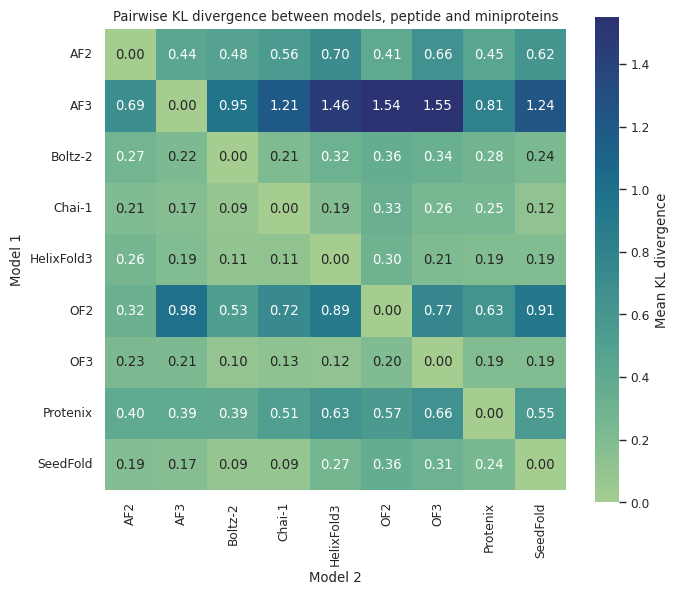

In [65]:
plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    kl_matrix,
    cmap="crest",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Mean KL divergence"}
)

ax.set_xlabel("Model 2")
ax.set_ylabel("Model 1")
ax.set_title("Pairwise KL divergence between models, peptide and miniproteins")

plt.tight_layout()
plt.show()

B. Per-binder per-method distribution

This answers:

For one binder, how different are AF2 vs AF3 vs Protenix in where they contact the target?

In [13]:
binder_method_residue_counts = (
    target_long_df
    .groupby(["binder_sequence", "method", "target_resseq"])
    .size()
    .reset_index(name="count")
)

def build_binder_method_matrix(df_one_binder, pseudocount=1e-6):
    """
    df_one_binder: rows for one binder only
    returns smoothed probability matrix indexed by method
    """
    mat = (
        df_one_binder
        .pivot(index="method", columns="target_resseq", values="count")
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    mat = mat + pseudocount
    mat = mat.div(mat.sum(axis=1), axis=0)
    return mat

def pairwise_kl_for_binder(df_one_binder, binder_name, pseudocount=1e-6):
    prob_mat = build_binder_method_matrix(df_one_binder, pseudocount=pseudocount)
    methods = prob_mat.index.tolist()

    rows = []
    for m1 in methods:
        for m2 in methods:
            p = prob_mat.loc[m1].values
            q = prob_mat.loc[m2].values
            rows.append({
                "binder_sequence": binder_name,
                "method_1": m1,
                "method_2": m2,
                "kl_divergence": kl_divergence(p, q),
            })

    return pd.DataFrame(rows)


In [14]:
all_binder_results = []

for binder, subdf in binder_method_residue_counts.groupby("binder_sequence"):
    result_df = pairwise_kl_for_binder(subdf, binder_name=binder, pseudocount=1e-6)
    all_binder_results.append(result_df)

binder_kl_df = pd.concat(all_binder_results, ignore_index=True)

print(binder_kl_df.head())

                                     binder_sequence method_1    method_2  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         AF3   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2     Boltz-2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2      Chai-1   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2  HelixFold3   

   kl_divergence  
0       0.000000  
1       4.763440  
2       5.345196  
3       5.716755  
4       3.488401  


for a single binder-method structure, the distribution is effectively:

uniform over the contacted target residues and zero over all non-contacted residues

So for one binder:

if AF2 contacts 20 target residues, each gets roughly probability 1/20

if AF3 contacts 10 target residues, each gets roughly probability 1/10

it means KL is measuring:
how different the contacted target-residue sets are, plus how broad/narrow each interface is

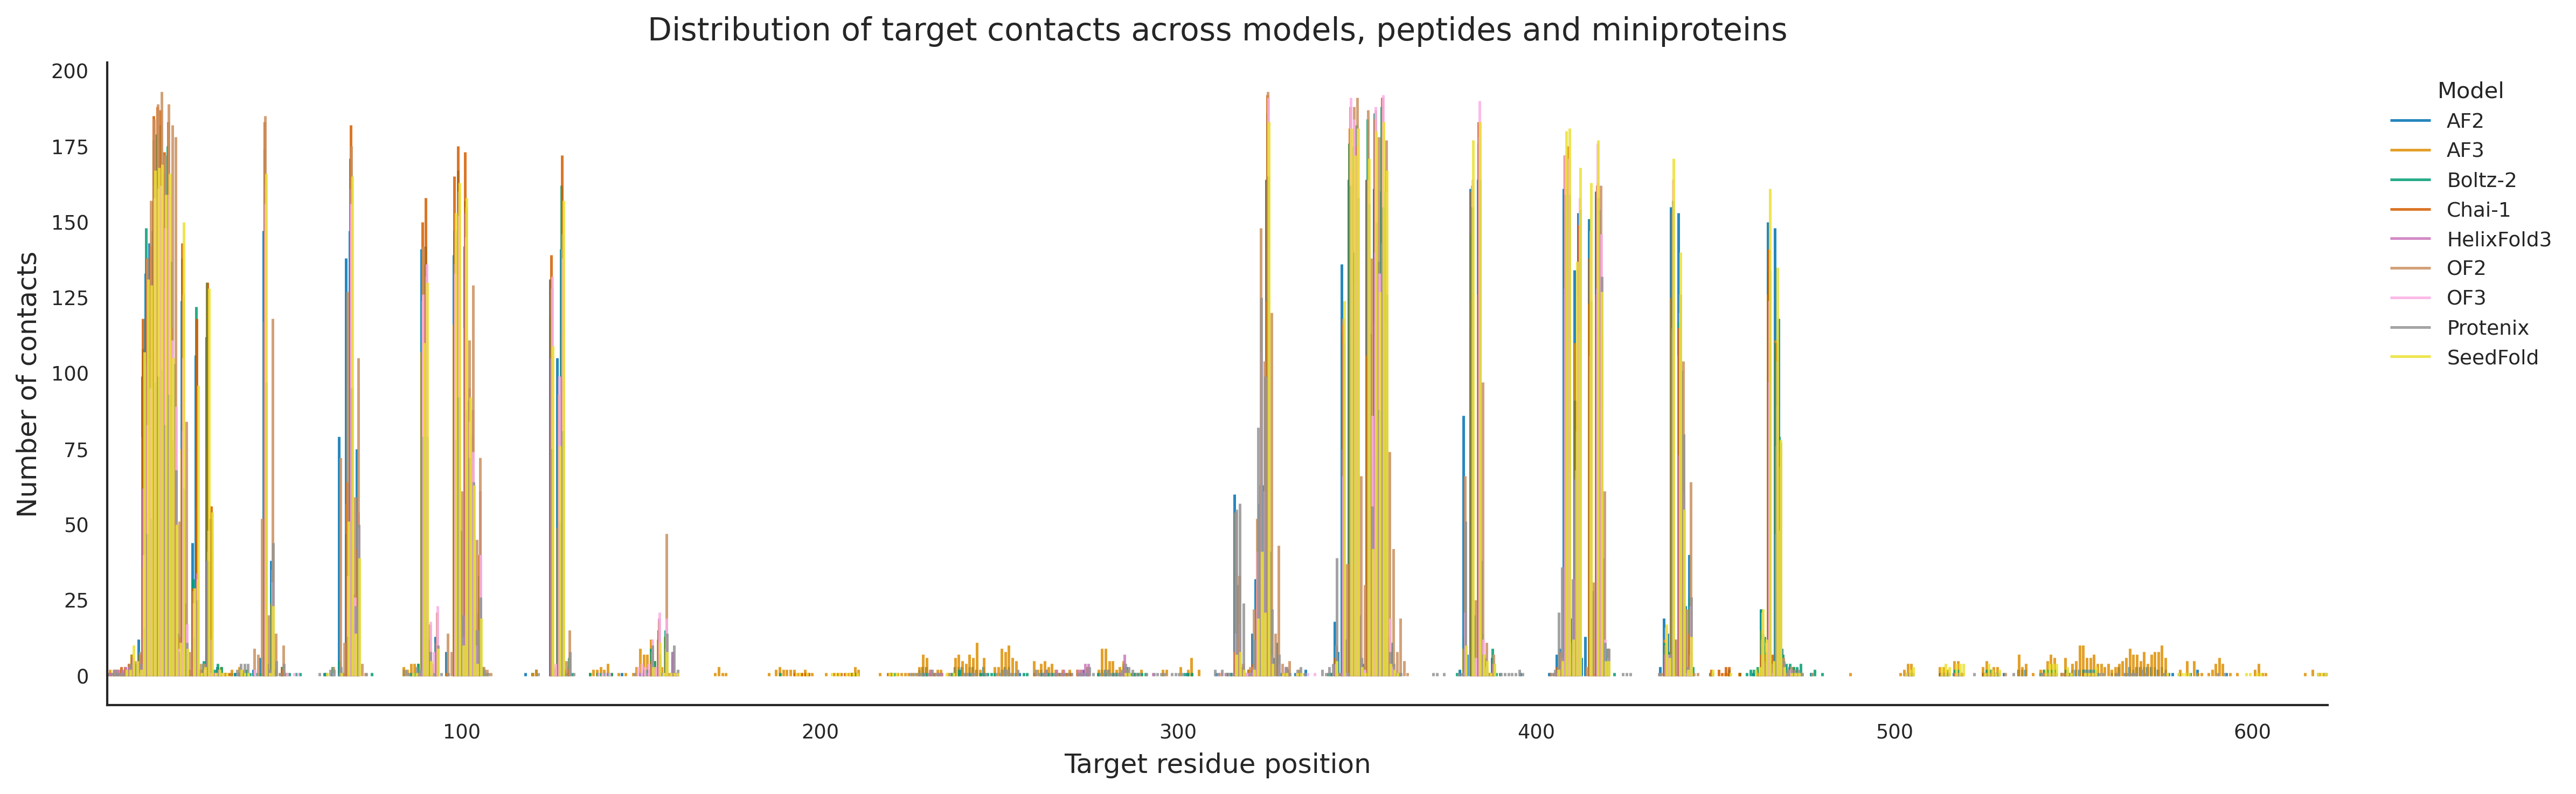

In [67]:
plot_df = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .reset_index(name="n_contacts")
)

method_order = sorted(plot_df["method"].unique())
palette = sns.color_palette("colorblind", n_colors=len(method_order))
color_map = dict(zip(method_order, palette))

offset_values = np.linspace(-0.35, 0.35, len(method_order))
offset_map = dict(zip(method_order, offset_values))

sns.set_theme(style="white", context="paper")

fig, ax = plt.subplots(figsize=(16, 5), dpi=300)

for method in method_order:
    sub = plot_df[plot_df["method"] == method]
    xvals = sub["target_resseq"] + offset_map[method]

    ax.vlines(
        x=xvals,
        ymin=0,
        ymax=sub["n_contacts"],
        color=color_map[method],
        linewidth=1.2,
        alpha=0.85,
        label=method,
    )

ax.set_xlim(1, 621)
ax.set_xlabel("Target residue position", fontsize=12)
ax.set_ylabel("Number of contacts", fontsize=12)
ax.set_title("Distribution of target contacts across models, peptides and miniproteins", fontsize=14, pad=10)

ax.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

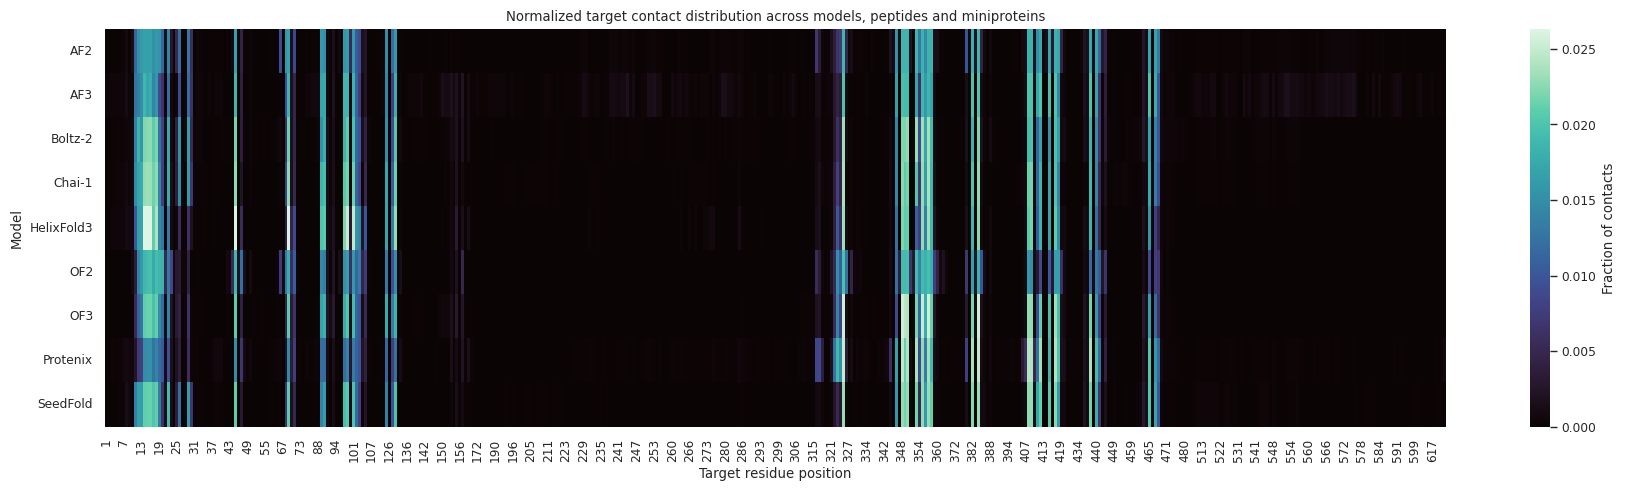

In [69]:

# Count how many times each method contacts each target residue
contact_counts = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .reset_index(name="n_contacts")
)

# Pivot to method x residue matrix
contact_matrix = (
    contact_counts
    .pivot(index="method", columns="target_resseq", values="n_contacts")
    .fillna(0)
)

contact_fraction_matrix = contact_matrix.div(contact_matrix.sum(axis=1), axis=0).fillna(0)

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(18, 5))
ax = sns.heatmap(
    contact_fraction_matrix,
    cmap="mako",
    cbar_kws={"label": "Fraction of contacts"}
)

ax.set_xlabel("Target residue position")
ax.set_ylabel("Model")
ax.set_title("Normalized target contact distribution across models, peptides and miniproteins")

plt.tight_layout()
plt.show()

In [86]:
rmsd_mean = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)["binder_ca_rmsd_align_target_shell"]
    .mean()
)

rmsd_median = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)["binder_ca_rmsd_align_target_shell"]
    .median()
)

In [90]:
rmsd_matrix = (
    rmsd_median
    .pivot(index="method_1", columns="method_2", values="binder_ca_rmsd_align_target_shell")
)
rmsd_matrix = rmsd_matrix.combine_first(rmsd_matrix.T)

method_order = sorted(set(rmsd_matrix.index) | set(rmsd_matrix.columns))
rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

In [91]:
for m in rmsd_matrix.index:
    rmsd_matrix.loc[m, m] = 0.0

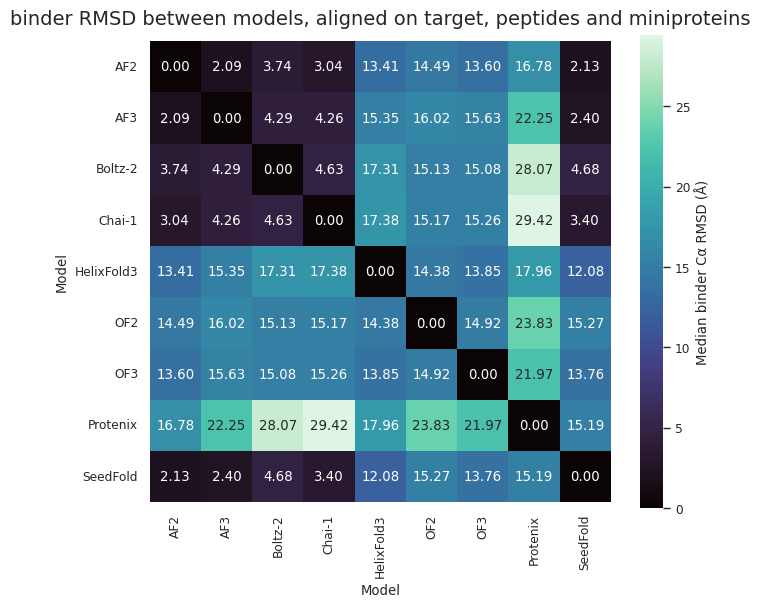

In [93]:
sns.set_theme(style="white", context="paper")

plt.figure(figsize=(7, 6))

ax = sns.heatmap(
    rmsd_matrix,
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Median binder Cα RMSD (Å)"}
)

ax.set_title("binder RMSD between models, aligned on target, peptides and miniproteins", fontsize=14, pad=12)
ax.set_xlabel("Model")
ax.set_ylabel("Model")

plt.tight_layout()
plt.show()

In [110]:
ref = "AF3"
rmsd_col = "binder_ca_rmsd_align_target_shell"  # adjust if needed

af3_as_1 = plot_rmsd[plot_rmsd["method_1"] == ref].copy()
af3_as_1["other_method"] = af3_as_1["method_2"]

af3_as_2 = plot_rmsd[plot_rmsd["method_2"] == ref].copy()
af3_as_2["other_method"] = af3_as_2["method_1"]

af3_all = pd.concat([af3_as_1, af3_as_2], ignore_index=True)

print(sorted(af3_all["other_method"].unique()))

['AF2', 'Boltz-2', 'Chai-1', 'HelixFold3', 'OF2', 'OF3', 'Protenix', 'SeedFold']


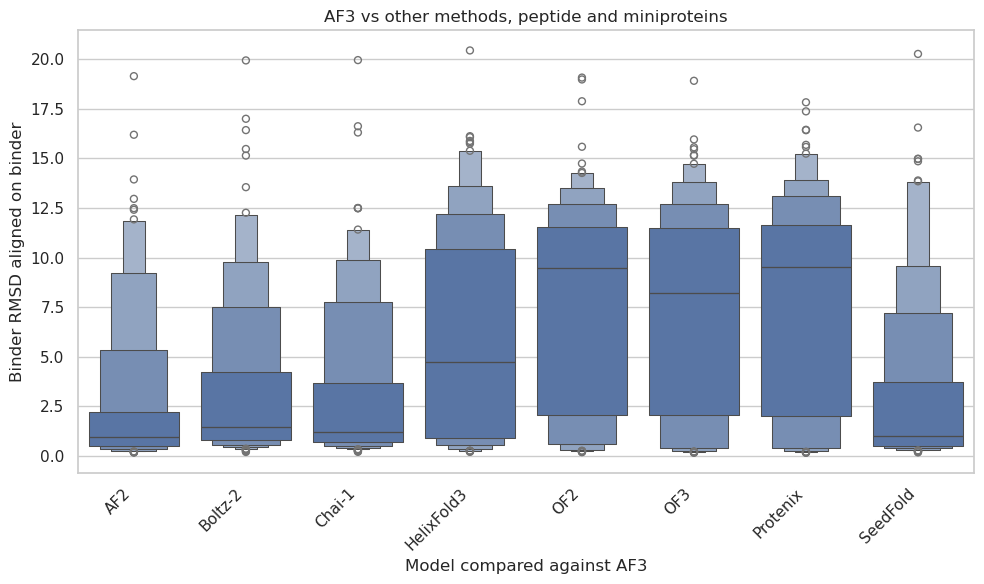

In [104]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=af3_all,
    x="other_method",
    y=rmsd_col,
    order=sorted(af3_all["other_method"].unique()),
    width_method="linear"
)

plt.xlabel("Model compared against AF3")
plt.ylabel("Binder RMSD aligned on binder")
plt.title("AF3 vs other methods, peptide and miniproteins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

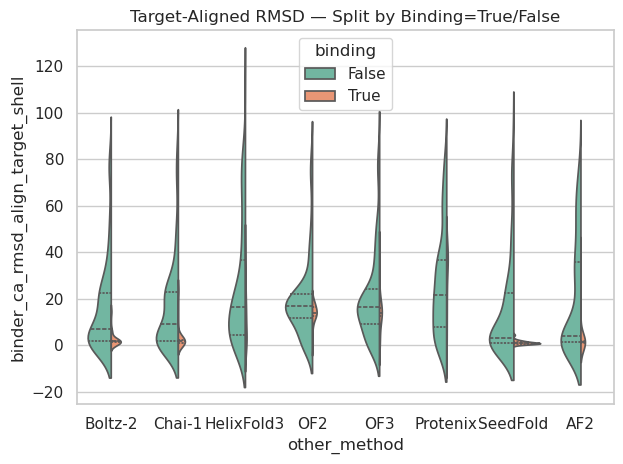

In [112]:

sns.violinplot(
    data=af3_all,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    hue="binding",             # split by True/False
    split=True,                # the magic option
    inner="quartile",          # shows quartile lines
    palette="Set2"
)

plt.title("Target-Aligned RMSD — Split by Binding=True/False")
plt.tight_layout()
plt.show()
